### Quantum Phase Estimation (QPE)

QPE estimates the phase φ in the eigenvalue equation: U|ψ⟩ = e^(2πiφ)|ψ⟩

This notebook implements QPE for:
1. A basic 3-qubit example
2. A 4-qubit example with Y-gate unitary (φ = 1/4)
3. A 5-qubit example estimating φ = 0.8125 (13/16)

In [15]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import QFT

In [17]:
def blochSphere(circuit: QuantumCircuit):
   
    qc = circuit.copy()               
    qc.save_statevector()            

    sim = AerSimulator(method='statevector')
    tqc = transpile(qc, sim)
    result = sim.run(tqc).result()

    state = result.get_statevector(tqc)    
    fig = plot_bloch_multivector(state)   
    plt.show()
    return fig

In [19]:
def histogramRep(circuit: QuantumCircuit, shots: int = 1024):
   
    qch = circuit.copy()            
    qch.measure_all()                 

    sim = AerSimulator()
    tqc = transpile(qch, sim)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    fig = plot_histogram(counts)      
    plt.show()
    return fig

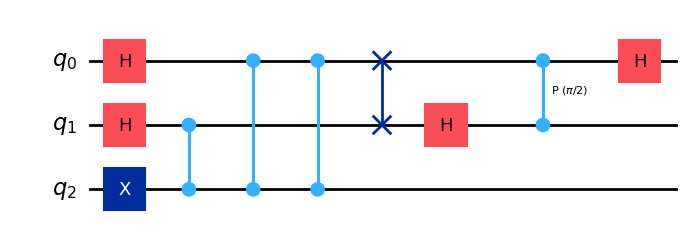

In [27]:
qpe_3qubit = QuantumCircuit(3)
qpe_3qubit.x(2)
qpe_3qubit.h(0)
qpe_3qubit.h(1)
qpe_3qubit.cz(1,2)
qpe_3qubit.cz(0,2)
qpe_3qubit.cz(0,2)
qpe_3qubit.swap (0,1)
qpe_3qubit.h(1)
qpe_3qubit.cp(np.pi/2,1,0)
qpe_3qubit.h(0)
qpe_3qubit.draw('mpl')

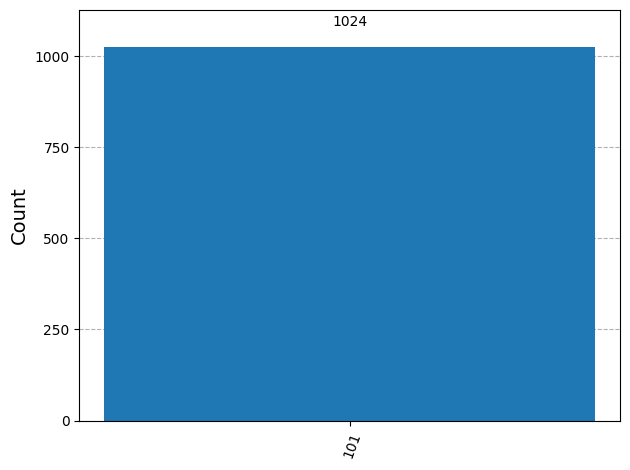

In [29]:
histogramRep(qpe_3qubit)

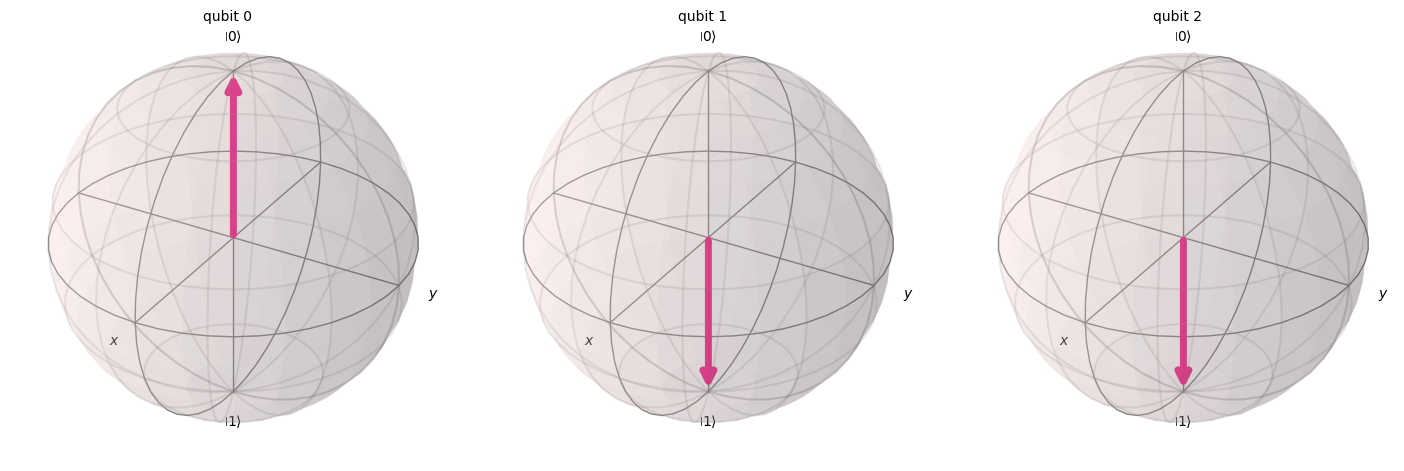

In [33]:
blochSphere(qpe_3qubit)

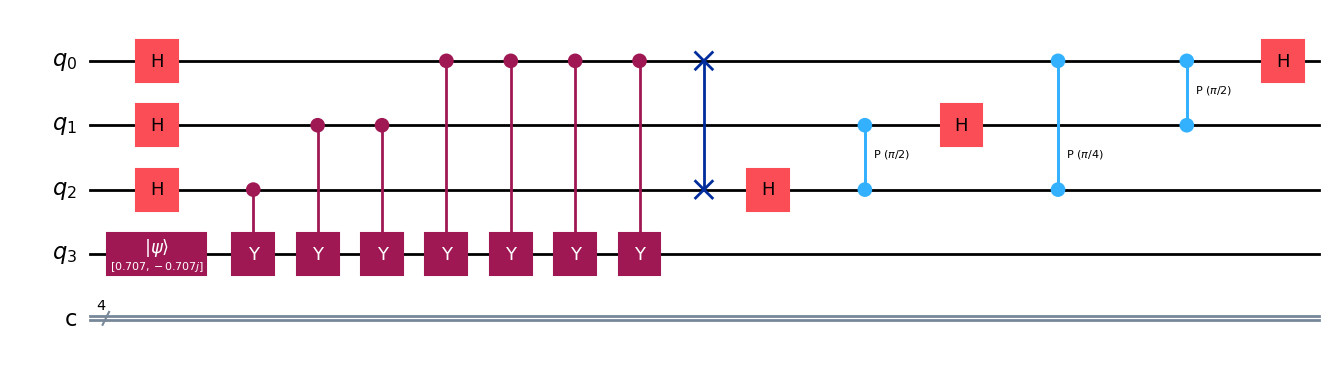

In [25]:
qpe_4qubit = QuantumCircuit(4,4)
qpe_4qubit.h(0)
qpe_4qubit.h(1)
qpe_4qubit.h(2)
initial_state = [1/np.sqrt(2), -1j/np.sqrt(2)]
qpe_4qubit.initialize(initial_state, 3)
qpe_4qubit.cy(2,3)

#redundant as 2 are applies
qpe_4qubit.cy(1,3)
qpe_4qubit.cy(1,3)

for i in range(4):
    qpe_4qubit.cy(0,3) #redundant as they are 4 so will be reduced to identity

qpe_4qubit.swap (0,2)
qpe_4qubit.h(2)
qpe_4qubit.cp(np.pi/2,1,2)
qpe_4qubit.h(1)
qpe_4qubit.cp(np.pi/4,0,2)
qpe_4qubit.cp(np.pi/2,0,1)
qpe_4qubit.h(0)
qpe_4qubit.draw('mpl')

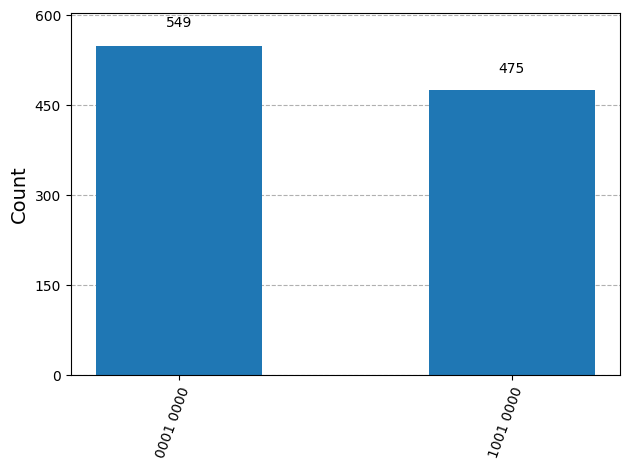

In [35]:
histogramRep(qpe_4qubit)

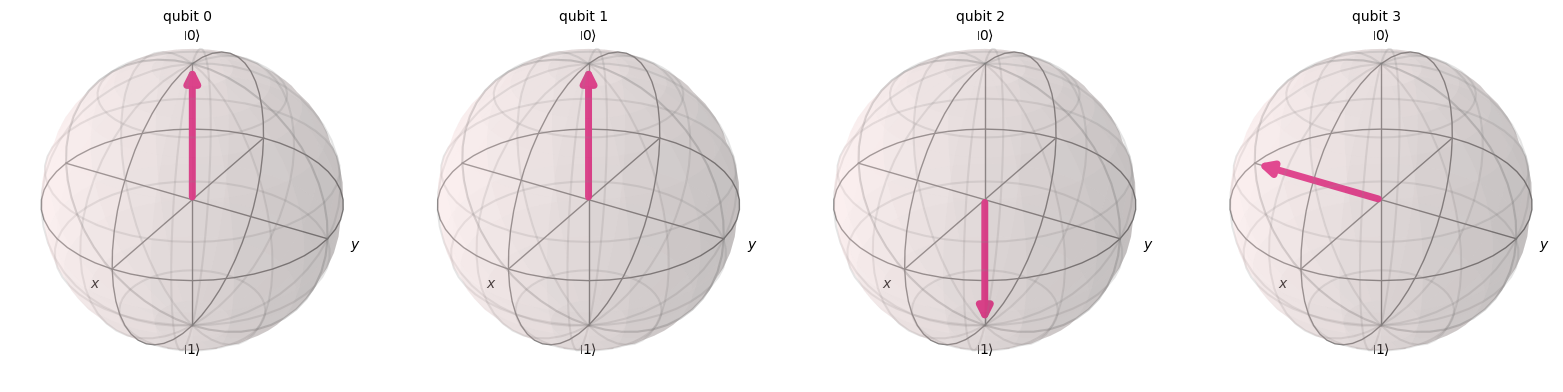

In [39]:
blochSphere(qpe_4qubit)

### Problem: Estimate φ = 0.8125
The unitary U has eigenvalue e^(2πi × 0.8125).
With 4 counting qubits, we expect to measure |1101⟩ = 13 in decimal → 13/16 = 0.8125 

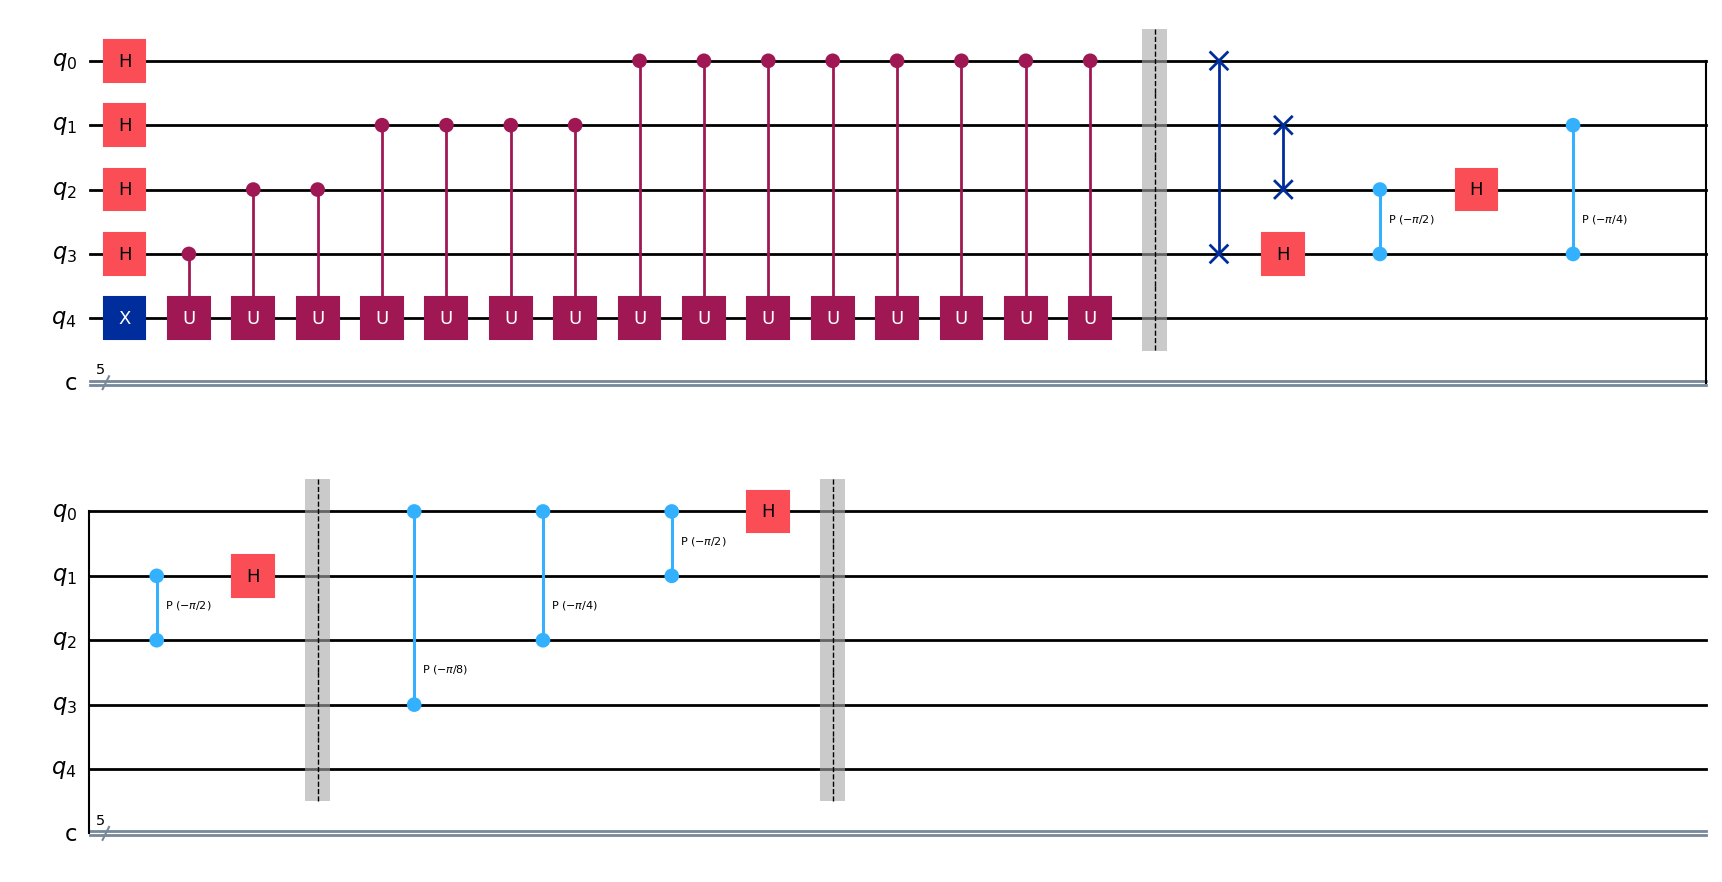

In [43]:
#Problem 1 from PhaseEstimation Pdf
U_matrix = [[1,0],[0, np.exp(2j * np.pi * 0.8125)]] 
U_gate = UnitaryGate(U_matrix, label='U')
Controlled_U_gate = U_gate.control(num_ctrl_qubits=1)
PE = QuantumCircuit(5,5)

for i in range(4):
    PE.h(i)
    
PE.x(4)


PE.append(Controlled_U_gate,[3,4])

PE.append(Controlled_U_gate,[2,4])
PE.append(Controlled_U_gate,[2,4])

for _ in range(4):
    PE.append(Controlled_U_gate, [1, 4])
    
for _ in range(8):
    PE.append(Controlled_U_gate, [0, 4])
PE.barrier()


PE.swap (0,3)
PE.swap (1,2)
PE.h(3)
PE.cp(-np.pi/2,2,3)
PE.h(2)
PE.cp(-np.pi/4,1,3)
PE.cp(-np.pi/2,1,2)
PE.h(1)
PE.barrier()
PE.cp(-np.pi/8,0,3)
PE.cp(-np.pi/4,0,2)
PE.cp(-np.pi/2,0,1)
PE.h(0)

PE.barrier()


PE.draw('mpl')

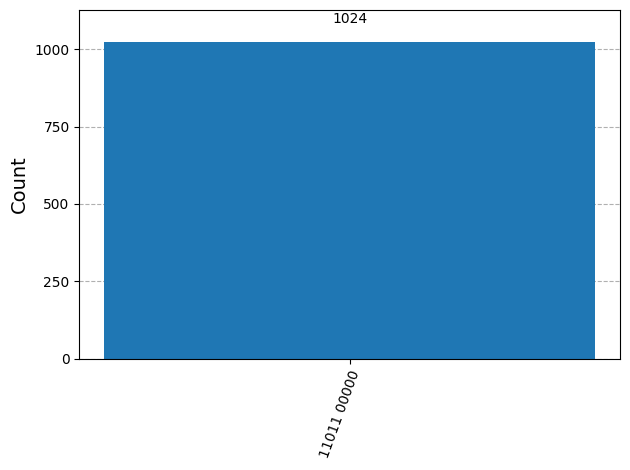

In [45]:
histogramRep(PE)

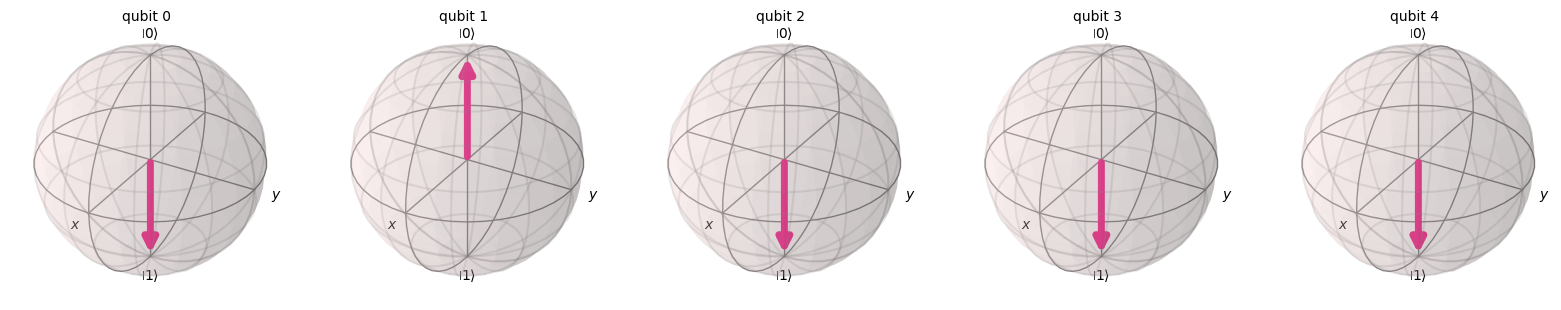

In [47]:
blochSphere(PE)